# Praktikum Hari 1: Fondasi Data dan Machine Learning
Python untuk Sistem Cerdas

Nama: Muhammad Akyas Febryansah | NIM: V3925029

Studi kasus: triase pasien klinik (`data_triase_klinik.csv`)

## A.1 Import Library dan Membaca Data

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data_triase_klinik.csv')
df.head()

,id_pasien,tanggal_kunjungan,usia,jenis_kelamin,sistolik,diastolik,nadi,suhu,spo2,laju_napas,keluhan,tindakan_lanjut,kategori_triase
0,P0052,2025-02-17,33,P,105.0,68.0,110.0,36.7,94.0,12.0,gatal pada kulit,Pulang,Non-Urgent
1,P0523,2025-07-06,77,P,132.0,96.0,87.0,36.7,98.0,22.0,sakit kepala ringan,Pulang,Non-Urgent
2,P0180,2025-09-02,80,P,129.0,74.0,90.0,36.4,NaN,22.0,pingsan tiba-tiba,Rawat Inap,Urgent
3,P1174,2025-03-25,12,P,115.0,67.0,64.0,37.0,93.0,21.0,kontrol rutin tekanan darah,Pulang,Non-Urgent
4,P0938,2025-10-25,1,L,132.0,89.0,85.0,35.5,150.0,23.0,demam ringan,Pulang,Non-Urgent


## A.2 Eksplorasi Awal dan Pemeriksaan Kualitas Data

In [2]:
print('Ukuran data:', df.shape)
df.info()

Ukuran data: (1225, 13)
<class 'pandas.DataFrame'>
RangeIndex: 1225 entries, 0 to 1224
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_pasien          1225 non-null   str    
 1   tanggal_kunjungan  1225 non-null   str    
 2   usia               1225 non-null   int64  
 3   jenis_kelamin      1225 non-null   str    
 4   sistolik           1225 non-null   float64
 5   diastolik          1225 non-null   float64
 6   nadi               1225 non-null   float64
 7   suhu               1171 non-null   float64
 8   spo2               1177 non-null   float64
 9   laju_napas         1147 non-null   float64
 10  keluhan            1225 non-null   str    
 11  tindakan_lanjut    1225 non-null   str    
 12  kategori_triase    1225 non-null   str    
dtypes: float64(6), int64(1), str(6)
memory usage: 124.5 KB


In [3]:
print('Jumlah missing value per kolom:')
print(df.isnull().sum())
print('\nJumlah baris duplikat:', df.duplicated().sum())
print('\nIsi kolom jenis_kelamin:', df['jenis_kelamin'].unique())
print('\nDistribusi label:')
print(df['kategori_triase'].value_counts(normalize=True).round(3))

Jumlah missing value per kolom:
id_pasien             0
tanggal_kunjungan     0
usia                  0
jenis_kelamin         0
sistolik              0
diastolik             0
nadi                  0
suhu                 54
spo2                 48
laju_napas           78
keluhan               0
tindakan_lanjut       0
kategori_triase       0
dtype: int64

Jumlah baris duplikat: 25

Isi kolom jenis_kelamin: <StringArray>
['P', 'L', 'l', 'Laki-laki', 'Perempuan', 'p']
Length: 6, dtype: str

Distribusi label:
kategori_triase
Non-Urgent    0.779
Urgent        0.221
Name: proportion, dtype: float64


In [4]:
df.describe().round(2)

,usia,sistolik,diastolik,nadi,suhu,spo2,laju_napas
count,1225.00,1225.00,1225.00,1225.00,1171.00,1177.00,1147.00
mean,44.44,123.36,76.81,88.66,37.09,96.01,19.05
std,25.58,21.09,14.84,17.30,2.32,4.27,4.06
min,1.00,0.00,23.00,27.00,0.00,84.00,8.00
25%,23.00,110.00,67.00,78.00,36.70,94.00,16.00
50%,44.00,124.00,76.00,89.00,37.20,96.00,19.00
75%,67.00,137.00,87.00,101.00,37.70,98.00,22.00
max,89.00,192.00,131.00,150.00,39.70,150.00,33.00


## A.3 NumPy: Looping vs Vektorisasi

In [5]:
sis = df['sistolik'].to_numpy()
dia = df['diastolik'].to_numpy()

# Cara 1: looping satu per satu
mulai = time.perf_counter()
map_loop = []
for i in range(len(sis)):
    map_loop.append((sis[i] + 2 * dia[i]) / 3)
waktu_loop = time.perf_counter() - mulai

# Cara 2: vektorisasi NumPy (seluruh array dihitung sekaligus)
mulai = time.perf_counter()
map_vec = (sis + 2 * dia) / 3
waktu_vec = time.perf_counter() - mulai

print(f'Looping     : {waktu_loop*1000:.3f} ms')
print(f'Vektorisasi : {waktu_vec*1000:.3f} ms')
print('Hasil sama? ', np.allclose(map_loop, map_vec))

Looping     : 0.599 ms
Vektorisasi : 0.067 ms
Hasil sama?  True


## A.4 Visualisasi EDA

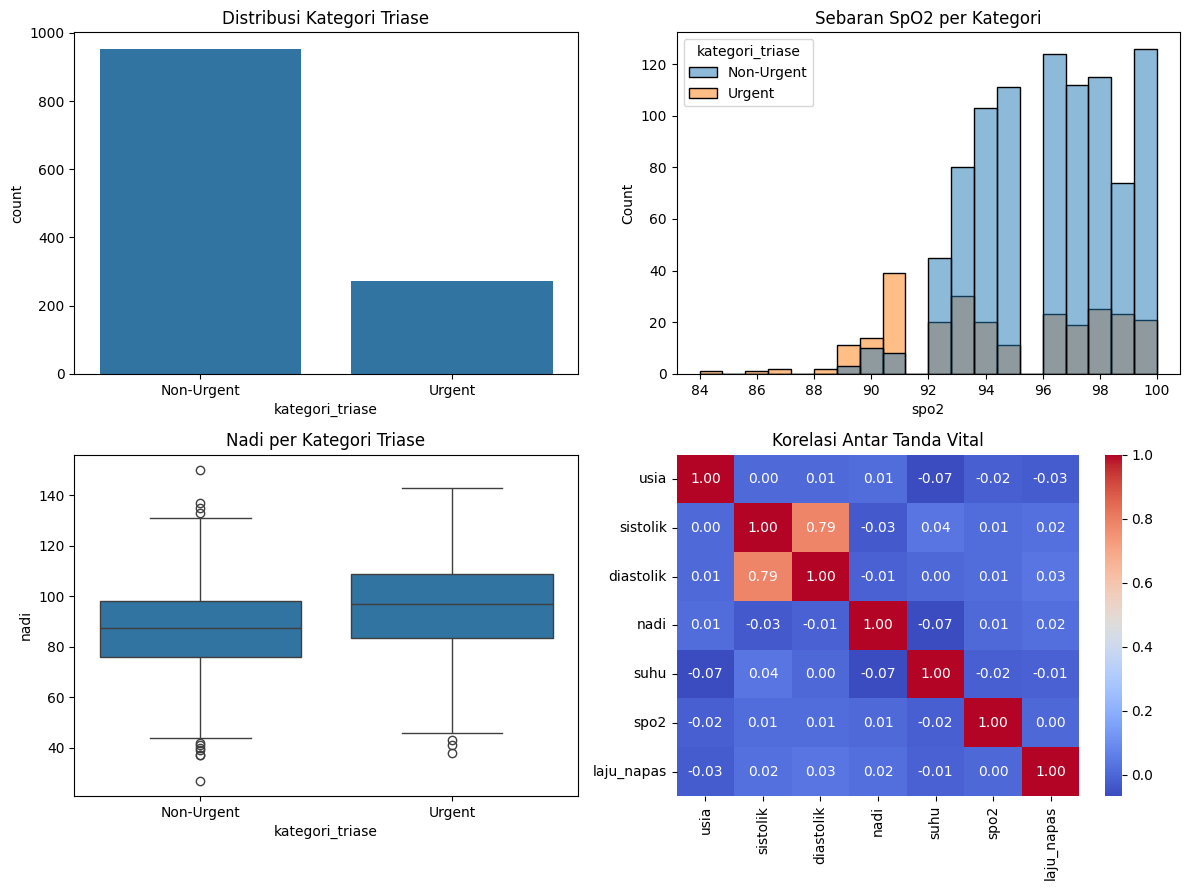

In [6]:
fig, ax = plt.subplots(2, 2, figsize=(12, 9))

sns.countplot(data=df, x='kategori_triase', ax=ax[0, 0])
ax[0, 0].set_title('Distribusi Kategori Triase')

sns.histplot(data=df[df['spo2'] <= 100], x='spo2',
             hue='kategori_triase', bins=20, ax=ax[0, 1])
ax[0, 1].set_title('Sebaran SpO2 per Kategori')

sns.boxplot(data=df, x='kategori_triase', y='nadi', ax=ax[1, 0])
ax[1, 0].set_title('Nadi per Kategori Triase')

kolom_num = ['usia', 'sistolik', 'diastolik', 'nadi',
             'suhu', 'spo2', 'laju_napas']
sns.heatmap(df[kolom_num].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', ax=ax[1, 1])
ax[1, 1].set_title('Korelasi Antar Tanda Vital')

plt.tight_layout()
plt.show()

### Insight EDA (A.4)
1. **Label tidak seimbang**: sekitar 78% Non-Urgent dan 22% Urgent. Dampaknya, accuracy saja bisa menipu (model yang selalu menebak Non-Urgent sudah dapat ~78%). Evaluasi harus pakai recall dan F1, dan split harus pakai `stratify=y`.
2. **SpO2 pasien Urgent lebih rendah**: hampir semua pasien dengan SpO2 di bawah 92 berkategori Urgent, median Urgent 94 vs Non-Urgent 96. SpO2 kemungkinan jadi fitur penting, dan ambang 92 masuk akal dipakai di baseline rule-based.
3. **Nadi pasien Urgent cenderung lebih tinggi** (median sekitar 97 vs 87), tapi rentang kedua kelas masih banyak tumpang tindih. Artinya nadi membantu tapi tidak cukup sendirian, model perlu menggabungkan beberapa tanda vital.
4. **Korelasi antar tanda vital rendah**, kecuali sistolik dan diastolik (0,79). Tiap fitur membawa informasi yang berbeda, sedangkan fitur turunan MAP akan sangat berkorelasi dengan keduanya sehingga perlu diwaspadai redundansinya.

## A.5 Pembersihan Data

In [7]:
df_bersih = df.copy()

# 1) Hapus baris duplikat
df_bersih = df_bersih.drop_duplicates()

# 2) Seragamkan penulisan kategori
peta_jk = {'L': 'L', 'l': 'L', 'Laki-laki': 'L',
           'P': 'P', 'p': 'P', 'Perempuan': 'P'}
df_bersih['jenis_kelamin'] = df_bersih['jenis_kelamin'].map(peta_jk)

# 3) Nilai yang mustahil secara medis diubah menjadi NaN
df_bersih.loc[df_bersih['spo2'] > 100, 'spo2'] = np.nan
df_bersih.loc[df_bersih['suhu'] < 30, 'suhu'] = np.nan
df_bersih.loc[df_bersih['sistolik'] < 50, 'sistolik'] = np.nan

# 4) Buang kolom identitas dan kolom yang baru diketahui SETELAH triase
df_bersih = df_bersih.drop(columns=['id_pasien', 'tindakan_lanjut'])

print('Ukuran setelah dibersihkan:', df_bersih.shape)
print(df_bersih['jenis_kelamin'].value_counts())
print(df_bersih.isnull().sum())

Ukuran setelah dibersihkan: (1200, 11)
jenis_kelamin
P    641
L    559
Name: count, dtype: int64
tanggal_kunjungan     0
usia                  0
jenis_kelamin         0
sistolik              4
diastolik             0
nadi                  0
suhu                 57
spo2                 52
laju_napas           78
keluhan               0
kategori_triase       0
dtype: int64


## A.6 Feature Engineering

In [8]:
# Fitur turunan berbasis pengetahuan domain
df_bersih['map'] = (df_bersih['sistolik'] + 2 * df_bersih['diastolik']) / 3
df_bersih['shock_index'] = df_bersih['nadi'] / df_bersih['sistolik']

# Binning usia menjadi kelompok
df_bersih['kelompok_usia'] = pd.cut(df_bersih['usia'],
                                    bins=[0, 12, 25, 45, 65, 120],
                                    labels=['anak', 'remaja', 'dewasa',
                                            'paruh_baya', 'lansia'])

# Label target menjadi angka: Urgent = 1, Non-Urgent = 0
df_bersih['target'] = (df_bersih['kategori_triase'] == 'Urgent').astype(int)

df_bersih[['sistolik', 'diastolik', 'nadi', 'map',
           'shock_index', 'usia', 'kelompok_usia', 'target']].head()

,sistolik,diastolik,nadi,map,shock_index,usia,kelompok_usia,target
0,105.0,68.0,110.0,80.333333,1.047619,33,dewasa,0
1,132.0,96.0,87.0,108.000000,0.659091,77,lansia,0
2,129.0,74.0,90.0,92.333333,0.697674,80,lansia,1
3,115.0,67.0,64.0,83.000000,0.556522,12,anak,0
4,132.0,89.0,85.0,103.333333,0.643939,1,anak,0


## A.7 Split Data dan Menyusun Pipeline Preprocessing

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

fitur_num = ['usia', 'sistolik', 'diastolik', 'nadi', 'suhu',
             'spo2', 'laju_napas', 'map', 'shock_index']
fitur_kat = ['jenis_kelamin', 'kelompok_usia']

X = df_bersih[fitur_num + fitur_kat]
y = df_bersih['target']

# Split DULU, baru preprocessing (mencegah data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

prep_num = Pipeline([('imputer', SimpleImputer(strategy='median')),
                     ('scaler', StandardScaler())])
prep_kat = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                     ('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer([('num', prep_num, fitur_num),
                                  ('kat', prep_kat, fitur_kat)])

print('Data latih:', X_train.shape, '| Data uji:', X_test.shape)

Data latih: (960, 11) | Data uji: (240, 11)


## A.8 Membangun Baseline

In [10]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, f1_score

def laporan(nama, y_true, y_pred):
    print(f'{nama:<22} Accuracy={accuracy_score(y_true, y_pred):.3f} '
          f'Recall={recall_score(y_true, y_pred):.3f} '
          f'F1={f1_score(y_true, y_pred):.3f}')

# Baseline 1: tebak kelas terbanyak (tanpa belajar apa pun)
dummy = Pipeline([('prep', preprocessor),
                  ('model', DummyClassifier(strategy='most_frequent'))])
dummy.fit(X_train, y_train)
laporan('Dummy (kelas terbanyak)', y_test, dummy.predict(X_test))

# Baseline 2: aturan non-AI (threshold tanda vital)
def aturan_triase(d):
    return ((d['spo2'] < 92) | (d['sistolik'] < 90) | (d['nadi'] > 130) |
            (d['laju_napas'] > 24) | (d['suhu'] >= 39)).astype(int)
laporan('Rule-based', y_test, aturan_triase(X_test))

# Baseline 3: machine learning sederhana
logreg = Pipeline([('prep', preprocessor),
                   ('model', LogisticRegression(max_iter=1000))])
logreg.fit(X_train, y_train)
laporan('Logistic Regression', y_test, logreg.predict(X_test))

Dummy (kelas terbanyak) Accuracy=0.779 Recall=0.000 F1=0.000
Rule-based             Accuracy=0.829 Recall=0.509 F1=0.568


Logistic Regression    Accuracy=0.812 Recall=0.472 F1=0.526


**Pengamatan A.8:** Dummy punya accuracy 0,779 tapi recall 0, jadi tidak pernah menemukan pasien Urgent. Rule-based (F1 0,568) justru sedikit lebih baik dari Logistic Regression (F1 0,526), artinya model linear sederhana belum mengalahkan aturan klinis.

## A.9 Membandingkan Model dengan Cross-Validation

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

kandidat = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200,
                                            random_state=42),
}

for nama, model in kandidat.items():
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    skor = cross_val_score(pipe, X_train, y_train, cv=5, scoring='f1')
    print(f'{nama:<20} F1 (5-fold) = {skor.mean():.3f} ± {skor.std():.3f}')

Logistic Regression  F1 (5-fold) = 0.606 ± 0.093


Decision Tree        F1 (5-fold) = 0.661 ± 0.059


Random Forest        F1 (5-fold) = 0.699 ± 0.064


**Pengamatan A.9:** Random Forest punya F1 rata-rata tertinggi (0,699 ± 0,064) dengan simpangan yang relatif kecil, jadi dipilih sebagai model terbaik. Logistic Regression paling rendah dan simpangannya paling besar (± 0,093).

## A.10 Simulasi Data Leakage

In [12]:
# SENGAJA memasukkan kolom 'tindakan_lanjut' (hanya diketahui SETELAH triase)
df_bocor = df.drop_duplicates().copy()
df_bocor['target'] = (df_bocor['kategori_triase'] == 'Urgent').astype(int)
X_bocor = pd.get_dummies(df_bocor[['tindakan_lanjut']])
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_bocor, df_bocor['target'], test_size=0.2,
    stratify=df_bocor['target'], random_state=42)

model_bocor = LogisticRegression(max_iter=1000).fit(Xb_train, yb_train)
laporan('Model dengan leakage', yb_test, model_bocor.predict(Xb_test))

Model dengan leakage   Accuracy=0.979 Recall=1.000 F1=0.955


**Pengamatan A.10:** Skor hampir sempurna (accuracy 0,979, recall 1,0) karena `tindakan_lanjut` pada dasarnya adalah hasil triase itu sendiri. Model ini tidak bisa dipakai karena saat pasien datang kolom itu belum ada.

## A.11 Unsupervised Learning: Clustering dan Anomaly Detection

In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

vital = ['sistolik', 'nadi', 'suhu', 'spo2', 'laju_napas']
imp_scaler = Pipeline([('imputer', SimpleImputer(strategy='median')),
                       ('scaler', StandardScaler())])
X_vital = imp_scaler.fit_transform(df_bersih[vital])

for k in range(2, 7):
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_vital)
    print(f'k={k}: silhouette={silhouette_score(X_vital, km.labels_):.3f}')

km = KMeans(n_clusters=3, n_init=10, random_state=42).fit(X_vital)
df_bersih['cluster'] = km.labels_
print(df_bersih.groupby('cluster')[vital + ['target']].mean().round(2))

k=2: silhouette=0.138
k=3: silhouette=0.135
k=4: silhouette=0.135
k=5: silhouette=0.135


k=6: silhouette=0.144
         sistolik   nadi   suhu   spo2  laju_napas  target
cluster                                                   
0          138.83  89.04  37.85  96.70       19.49    0.18
1          118.20  85.27  37.16  92.65       18.23    0.33
2          115.26  90.78  36.73  97.67       19.36    0.17


In [14]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.03, random_state=42)
df_bersih['anomali'] = iso.fit_predict(X_vital)  # -1 = anomali, 1 = normal

print(df_bersih['anomali'].value_counts())
print('\nContoh pasien dengan pola tanda vital tidak biasa:')
print(df_bersih.loc[df_bersih['anomali'] == -1,
                    vital + ['kategori_triase']].head())

anomali
 1    1164
-1      36
Name: count, dtype: int64

Contoh pasien dengan pola tanda vital tidak biasa:
     sistolik   nadi  suhu  spo2  laju_napas kategori_triase
18      153.0   89.0  36.1  84.0        23.0          Urgent
39      152.0   41.0  37.5  89.0        17.0          Urgent
68      102.0   59.0  39.3  91.0        20.0          Urgent
127      74.0   90.0  38.5  92.0        10.0          Urgent
185     137.0  150.0  36.5  99.0        13.0      Non-Urgent


**Pengamatan A.11:** Silhouette score di semua k hanya sekitar 0,13 sampai 0,14, jadi pasien tidak terbagi ke kelompok yang benar-benar terpisah. Cluster 1 (SpO2 rata-rata paling rendah) punya proporsi Urgent tertinggi (33%). Dari 36 pasien yang ditandai anomali oleh Isolation Forest, contoh yang muncul sebagian besar Urgent, jadi anomali tanda vital cukup berkaitan dengan kondisi gawat.

## A.12 Feature Engineering untuk Teks dan Time Series

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=30)
X_teks = tfidf.fit_transform(df_bersih['keluhan'])

print('Ukuran matriks TF-IDF:', X_teks.shape)
bobot = pd.DataFrame(X_teks.toarray(), columns=tfidf.get_feature_names_out())
bobot['target'] = df_bersih['target'].values
print(bobot.groupby('target').mean().T
      .sort_values(1, ascending=False).head(8).round(3))

Ukuran matriks TF-IDF: (1200, 30)
target         0      1
dan        0.017  0.201
napas      0.008  0.179
sesak      0.008  0.179
dada       0.013  0.122
tiba       0.016  0.118
nyeri      0.066  0.104
batuk      0.076  0.086
menggigil  0.011  0.083


In [16]:
df_bersih['tanggal_kunjungan'] = pd.to_datetime(df_bersih['tanggal_kunjungan'])
harian = (df_bersih.groupby('tanggal_kunjungan').size()
          .asfreq('D', fill_value=0).to_frame('jumlah_pasien'))

harian['lag_1'] = harian['jumlah_pasien'].shift(1)
harian['lag_7'] = harian['jumlah_pasien'].shift(7)
harian['rolling_mean_7'] = harian['jumlah_pasien'].shift(1).rolling(7).mean()
harian['hari'] = harian.index.dayofweek

print(harian.dropna().head(8))

                   jumlah_pasien  lag_1  lag_7  rolling_mean_7  hari
tanggal_kunjungan                                                   
2025-01-08                     3    5.0    4.0        4.142857     2
2025-01-09                     3    3.0    1.0        4.000000     3
2025-01-10                     4    3.0    4.0        4.285714     4
2025-01-11                     2    4.0    5.0        4.285714     5
2025-01-12                     5    2.0    5.0        3.857143     6
2025-01-13                     4    5.0    5.0        3.857143     0
2025-01-14                     4    4.0    5.0        3.714286     1
2025-01-15                     4    4.0    3.0        3.571429     2


In [17]:
from sklearn.metrics.pairwise import cosine_similarity

# Knowledge base mini: potongan (chunk) dokumen RPS dan modul
dokumen = pd.DataFrame({'id': ['D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8'],
    'teks': [
    'Bobot penilaian: hasil proyek 80 persen, UTS 15 persen, UAS 5 persen.',
    'UTS dilaksanakan pada pertemuan 8 berupa praktik individual '
    'dengan dataset baru dan batas waktu.',
    'Evaluasi clustering memakai silhouette score, inertia atau WCSS, '
    'dan Davies-Bouldin Index.',
    'Metrik klasifikasi: accuracy, precision, recall, F1, dan ROC-AUC. '
    'Recall penting pada skrining kesehatan agar kasus positif tidak terlewat.',
    'Data leakage terjadi jika model memakai informasi yang belum tersedia '
    'saat prediksi. Lakukan split data sebelum imputasi dan scaling.',
    'YOLO adalah algoritma deteksi objek real-time. '
    'Kinerja deteksi dibaca dengan mAP dan IoU.',
    'Deployment model dapat dibuat dengan Streamlit atau Gradio '
    'sehingga pengguna mencoba model melalui antarmuka web.',
    'Standar minimal ketercapaian Sub-CPMK adalah skor 3 pada rubrik '
    'skala 1 sampai 4.']})

# Evaluation set: pertanyaan + dokumen yang benar (kunci)
eval_set = pd.DataFrame({
    'pertanyaan': [
        'Berapa persen bobot UTS?',
        'Bagaimana mencegah data leakage?',
        'Metrik apa untuk membaca hasil YOLO?',
        'Apa ukuran evaluasi clustering?',
        'Mengapa recall penting pada skrining kesehatan?',
        'Berapa skor minimal agar Sub-CPMK tercapai?',
        'Bagaimana pengguna mencoba model lewat web?',
        'Skor evaluasi apa yang dipakai untuk YOLO?',
        'Kapan ujian tengah semester diadakan?'],
    'dok_benar': ['D1', 'D5', 'D6', 'D3', 'D4', 'D8', 'D7', 'D6', 'D2']})

stopword = ['apa', 'yang', 'dan', 'untuk', 'pada', 'berapa', 'bagaimana',
            'mengapa', 'kapan', 'agar', 'dengan', 'adalah', 'atau', 'jika']
tfidf_rag = TfidfVectorizer(stop_words=stopword)
X_dok = tfidf_rag.fit_transform(dokumen['teks'])  # indeks dokumen

def retrieve(pertanyaan, k=3):
    skor = cosine_similarity(tfidf_rag.transform([pertanyaan]), X_dok)[0]
    urut = [i for i in skor.argsort()[::-1] if skor[i] > 0][:k]
    return list(dokumen['id'].iloc[urut]), skor[urut]

# Cari peringkat dokumen yang benar untuk setiap pertanyaan
peringkat = []
for q, benar in zip(eval_set['pertanyaan'], eval_set['dok_benar']):
    hasil, _ = retrieve(q, k=len(dokumen))
    # jika dokumen benar tidak terambil sama sekali, peringkat = tak hingga
    peringkat.append(hasil.index(benar) + 1 if benar in hasil else np.inf)
eval_set['peringkat'] = peringkat
eval_set['top3'] = [retrieve(q)[0] for q in eval_set['pertanyaan']]
print(eval_set[['pertanyaan', 'dok_benar', 'top3', 'peringkat']].to_string())

r = eval_set['peringkat']
print(f'\nRecall@1 = {(r <= 1).mean():.2f}')
print(f'Recall@3 = {(r <= 3).mean():.2f}')
print(f'MRR      = {(1 / r).mean():.2f}')

# Pertanyaan yang jawabannya TIDAK ada di knowledge base
hasil, skor = retrieve('Siapa rektor Universitas Sebelas Maret?')
print('\nPertanyaan di luar dokumen -> dokumen terambil:', hasil)

                                        pertanyaan dok_benar          top3  peringkat
0                         Berapa persen bobot UTS?        D1      [D1, D2]        1.0
1                 Bagaimana mencegah data leakage?        D5          [D5]        1.0
2             Metrik apa untuk membaca hasil YOLO?        D6  [D6, D1, D4]        1.0
3                  Apa ukuran evaluasi clustering?        D3          [D3]        1.0
4  Mengapa recall penting pada skrining kesehatan?        D4          [D4]        1.0
5      Berapa skor minimal agar Sub-CPMK tercapai?        D8          [D8]        1.0
6      Bagaimana pengguna mencoba model lewat web?        D7      [D7, D5]        1.0
7       Skor evaluasi apa yang dipakai untuk YOLO?        D6  [D8, D3, D6]        3.0
8            Kapan ujian tengah semester diadakan?        D2            []        inf

Recall@1 = 0.78
Recall@3 = 0.89
MRR      = 0.81

Pertanyaan di luar dokumen -> dokumen terambil: []


**Pengamatan A.12:** Kata "sesak", "napas", "dada", dan "tiba" paling membedakan keluhan Urgent. Pada retrieval, Recall@1 = 0,78, Recall@3 = 0,89, MRR = 0,81. Pertanyaan YOLO kedua ada di peringkat 3, pertanyaan "ujian tengah semester" gagal karena dokumen hanya menulis "UTS", dan pertanyaan di luar knowledge base tidak mengambil dokumen apa pun.

## A.13 Menyimpan Model dan Data Bersih

In [18]:
import joblib
import os

model_final = Pipeline([('prep', preprocessor),
                        ('model', RandomForestClassifier(n_estimators=200,
                                                         random_state=42))])
model_final.fit(X_train, y_train)
laporan('Random Forest (uji)', y_test, model_final.predict(X_test))

os.makedirs('models', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)
joblib.dump(model_final, 'models/baseline_triase.joblib')
df_bersih.to_csv('data/processed/data_triase_bersih.csv', index=False)
print('Model dan data bersih tersimpan.')

Random Forest (uji)    Accuracy=0.858 Recall=0.604 F1=0.653
Model dan data bersih tersimpan.
